In [1]:
from pyPLNmodels.models import fastPLN, fastPLNPCA, IMPS_PLN, log_likelihood
from pyPLNmodels.utils import build_block_Sigma, C_from_Sigma, sample_PLN
import torch
import pandas as pd 
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

Device  cuda


In [2]:
%load_ext autoreload

%autoreload 2

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else : 
    device = torch.device('cpu')
    
#device = torch.device('cpu') # think I can't use RTX A5000 right now, will check this later. 
torch.cuda.is_available()

True

In [4]:
d = 2
n = 1000;  p = 10000
q = 10

In [9]:
# 0 est pas mal 
#torch.manual_seed(0)
Sigma_sampling = 1*torch.from_numpy(build_block_Sigma(p,100)) #+ 0.5*torch.eye(p)
true_C = C_from_Sigma(Sigma_sampling, q)
true_C = true_C.to(device)
true_Sigma_sampling = true_C@(true_C.T)
true_beta =torch.randn((d, p), device = device)/2

covariates = torch.randn((n,d)).to(device)
O =  0*torch.randint(2,(n,p)).to(device)
Y, Z, _  = sample_PLN(true_C,true_beta, O, covariates)
Y = pd.DataFrame(Y.cpu().numpy())
covariates = pd.DataFrame(covariates.cpu().numpy())
O = pd.DataFrame(O.cpu().numpy())

In [10]:
Y.max().max()

3175.0

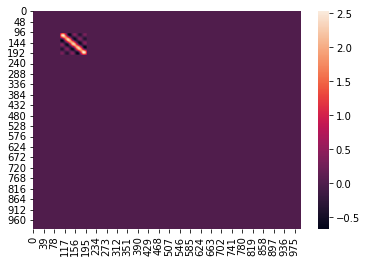

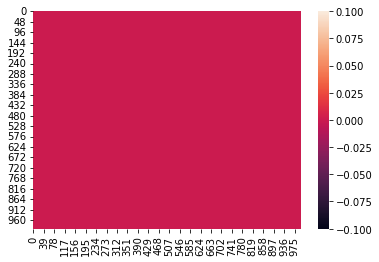

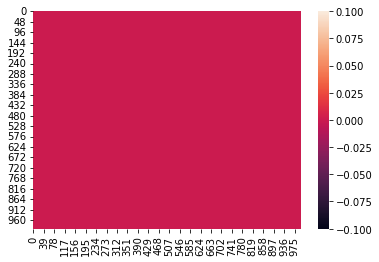

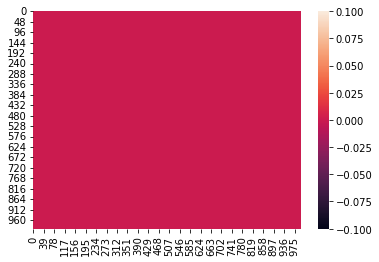

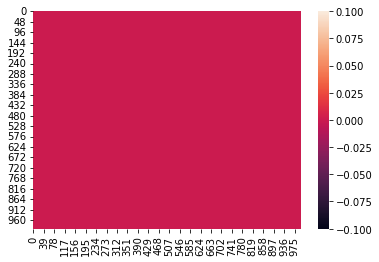

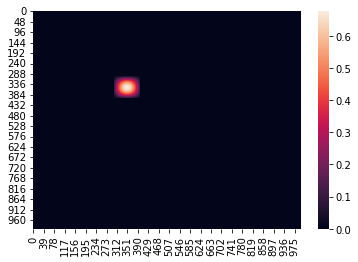

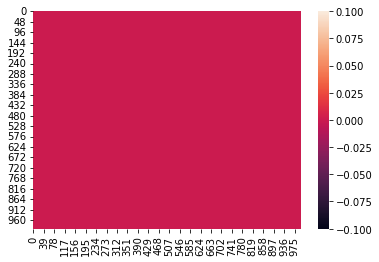

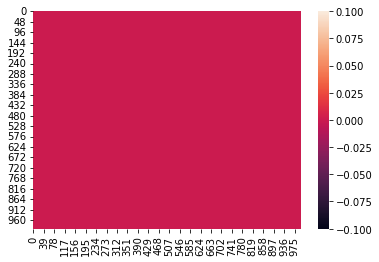

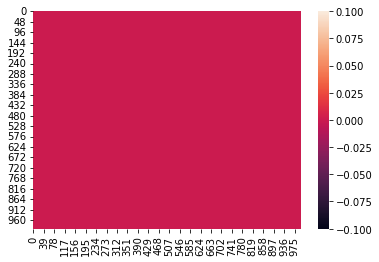

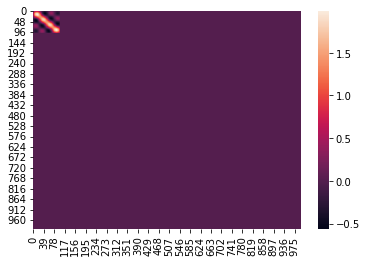

In [11]:
n_low = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]
n_high = np.array(n_low) + 1000
for i in range(10): 
    sns.heatmap(true_Sigma_sampling[n_low[i]:n_high[i], n_low[i]:n_high[i]].cpu())
    #sns.heatmap(true_Sigma_sampling[n_low[i]:n_high[i], n_low[i]:n_high[i]].cpu())
    plt.show()

In [28]:
imps.get_Sigma().max()

tensor(103.1820)

<AxesSubplot:>

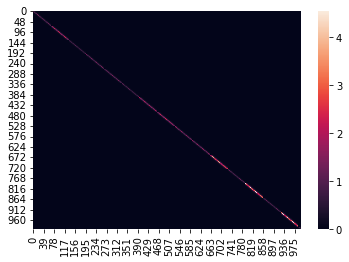

In [102]:
n_a = 0 
n_b = 1000
sns.heatmap(Sigma_sampling[n_a:n_b, n_a:n_b])

In [12]:
fast = fastPLN()
fast.fit(Y,O,covariates, good_init = True)

Initialization ...


RuntimeError: torch.linalg.cholesky: The factorization could not be completed because the input is not positive-definite (the leading minor of order 1003 is not positive-definite).

Last ELBO : -1280.5874847139846


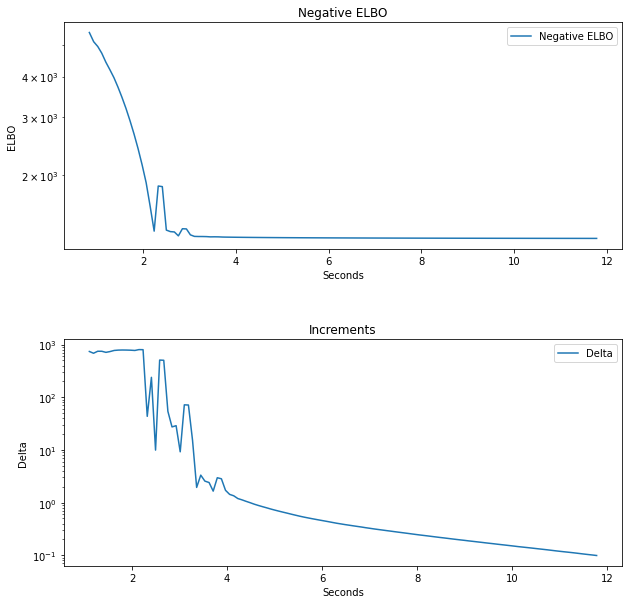

The heatmap only displays Sigma[:400,:400]


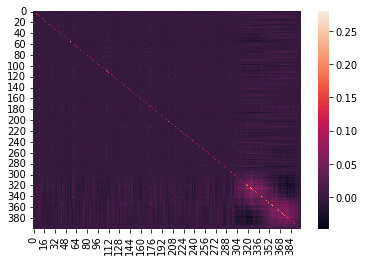

In [41]:
print(fast)

In [18]:
fastpca = fastPLNPCA(q = q)
fastpca.fit(Y,O,covariates,N_iter_max = 25000, good_init = True, tol = 0.00001)

Initialization ...
p is too large (>1500) to do a good initialization, random intialization is performed instead
Initialization finished
Tolerance 1e-05 reached in 6290 iterations


Best ELBO:  -12491.888388755387
The heatmap only displays Sigma[:400,:400]


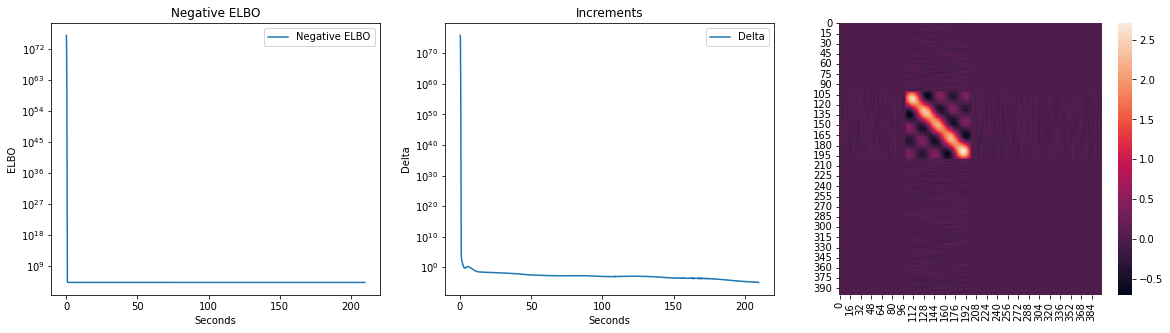

<Figure size 432x288 with 0 Axes>

In [19]:
print(fastpca)

In [40]:
fastpca.likelihood_list = list()
length = len(fastpca.running_times)
abscisse = fastpca.running_times

fig = plt.figure()

for beta,C in fastpca.all_params: 
    log_like = log_likelihood(fastpca.Y, fastpca.O, fastpca.covariates, C, beta, N_iter_mode = 10000, acc = 0.005).item()
    fastpca.likelihood_list.append(log_like)

saccaded_absc = [abscisse[i*fastpca.interval] for i in np.arange(len(fastpca.likelihood_list))]



plt.plot(saccaded_absc[int(len(saccaded_absc)/6):], 
           - np.array(fastpca.likelihood_list)[int(len(saccaded_absc)/6):], 
           label='Estimated negative log likelihood')
plt.plot(abscisse[int(length/6):], - np.array(fastpca.normalized_ELBOs)[int(length/6):], label='Negative ELBO')



plt.yscale('log')
plt.xlabel('Seconds')
plt.legend()
plt.title('ELBO vs log likelihood')
#plt.savefig('ELBOvslikelihood')

AttributeError: 'fastPLNPCA' object has no attribute 'all_params'

<Figure size 432x288 with 0 Axes>

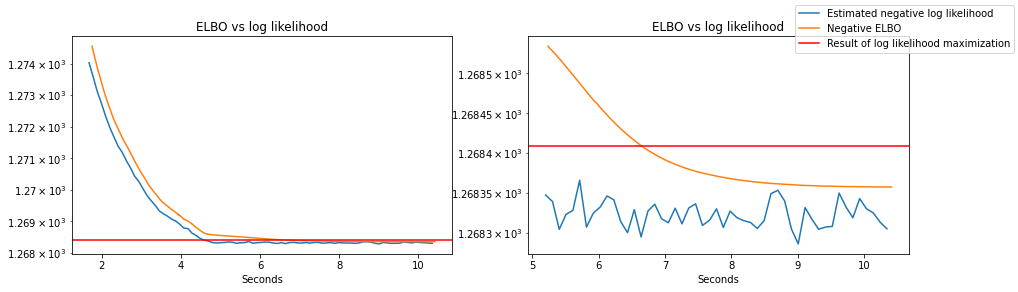

In [74]:
div = 6


fig, axes = plt.subplots(1,2, figsize = (15, 4))


axes[0].plot(saccaded_absc[int(len(saccaded_absc)/div):], 
            -np.array(fastpca.likelihood_list)[int(len(saccaded_absc)/div):], 
           label='Estimated negative log likelihood')
axes[0].plot(abscisse[int(length/div):],  -np.array(fastpca.normalized_ELBOs)[int(length/div):], label='Negative ELBO')


axes[0].axhline(best, c = 'red', label = 'Result of log likelihood maximization')
axes[0].set_yscale('log')
axes[0].set_xlabel('Seconds')
#axes[0].legend()
axes[0].set_title('ELBO vs log likelihood')

div = 2


axes[1].plot(saccaded_absc[int(len(saccaded_absc)/div):], 
            -np.array(fastpca.likelihood_list)[int(len(saccaded_absc)/div):], 
           label='Estimated negative log likelihood')
axes[1].plot(abscisse[int(length/div):],  -np.array(fastpca.normalized_ELBOs)[int(length/div):], label='Negative ELBO')


axes[1].axhline( best, c = 'red', label = 'Result of log likelihood maximization')
axes[1].set_yscale('log')
axes[1].set_xlabel('Seconds')
#axes[1].legend()
axes[1].set_title('ELBO vs log likelihood')


handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels)

plt.savefig('ELBOvslikelihood')

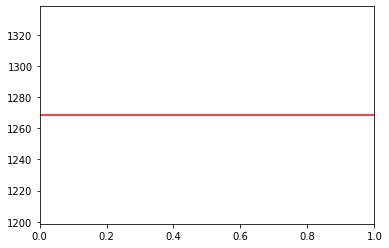

In [33]:
#imps = IMPS_PLN(q = q)
imps.fit(Y,O,covariates, verbose = True, good_init = True, batch_size = 10, acc = 0.01, lr = 0.00001, N_iter_max = 50)

  2%|█▎                                                               | 1/50 [00:27<22:11, 27.17s/it]

Average log likelihood :  -12499.199337465858


  4%|██▌                                                              | 2/50 [00:46<18:15, 22.82s/it]

Average log likelihood :  -12498.573155845621


  6%|███▉                                                             | 3/50 [01:05<16:13, 20.71s/it]

...

Average log likelihood :  -12808.070443378587
 Criterion updated :  13 / 15


 54%|██████████████████████████████████▌                             | 27/50 [08:50<07:46, 20.27s/it]

Average log likelihood :  -12807.45770588484
 Criterion updated :  14 / 15


 54%|██████████████████████████████████▌                             | 27/50 [09:10<07:48, 20.39s/it]

Average log likelihood :  -12806.19873614396
 Criterion updated :  15 / 15
Algorithm stopped after  27  iterations


In [29]:
best =-12492.15

Best likelihood:  -12492.152678257165
The heatmap only displays Sigma[:400,:400]


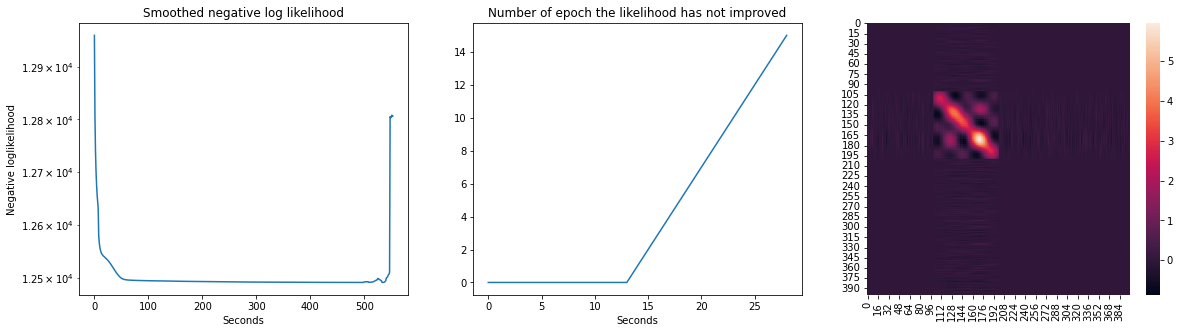

<Figure size 432x288 with 0 Axes>

In [34]:
print(imps)

<AxesSubplot:>

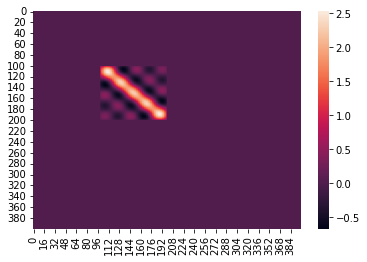

In [17]:
sns.heatmap(true_Sigma_sampling[0:400,0:400].cpu())

In [24]:
sig_list = [true_Sigma_sampling, fastpca.get_Sigma(), imps.get_Sigma()]

In [25]:
beta_list = [true_beta,  fastpca.get_beta(), imps.get_beta()]

In [26]:
title_list = ['Ground truth',  'VEM', 'Importance sampling']

In [27]:
time_list = ["", "3'", "160'"]

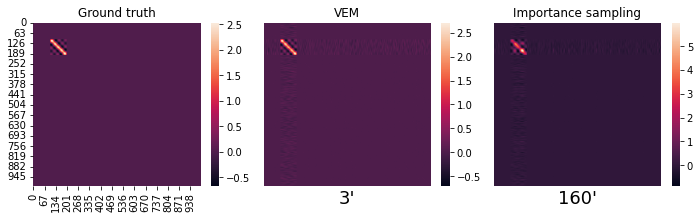

In [30]:
fig, axes = plt.subplots(1,3, figsize = (12,3))

for i, sig in enumerate(sig_list): 
    if i>0 : 
        sns.heatmap(sig.cpu()[0:1000,0:1000],ax = axes[i], yticklabels = [], xticklabels = [])
    else:
        sns.heatmap(sig[0:1000,0:1000].cpu(),ax = axes[i])
    axes[i].set_title(title_list[i])
    axes[i].set_xlabel(time_list[i], fontsize = 18)
    
plt.subplots_adjust(wspace=0.1) 
                    #hspace=0.35)

plt.savefig('Comparison_GT_2algs_n=1000,p=10000,q=10')
plt.show()

In [47]:
log_likelihood(Y,O, covariates, fastpca.C, fastpca.beta, acc = 1)

Intialization ...
Initalization done


RuntimeError: CUDA out of memory. Tried to allocate 78.00 MiB (GPU 0; 23.68 GiB total capacity; 11.32 GiB already allocated; 37.44 MiB free; 11.38 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF

In [147]:
for beta in beta_list: 
    print('MSE:', torch.mean((true_beta-beta)**2))

MSE: tensor(0.)
MSE: tensor(0.0010)
MSE: tensor(0.0006)
MSE: tensor(0.0006)


In [148]:
true_beta

tensor([[ 0.2786, -0.4316, -0.2520,  ..., -0.5498,  0.2828,  0.2062],
        [-0.8576, -0.2539,  0.3103,  ..., -0.7628,  1.1541,  0.0997]])

In [149]:
beta_list[2]

tensor([[ 0.2911, -0.4446, -0.2698,  ..., -0.5559,  0.3022,  0.2086],
        [-0.8620, -0.2528,  0.3079,  ..., -0.7492,  1.1719,  0.1473]])

In [48]:
a = torch.zeros(3).to('cuda')

Device  cuda


In [49]:
print(a)

tensor([0., 0., 0.], device='cuda:0')
